# **Modelo clasificatorio de calidad de manzanas**

In [1]:
# Instalación de librerías básicas
!pip install torch torchvision pandas numpy matplotlib scikit-learn seaborn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from  torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [3]:
def load_data_from_github():
    try:
        # Opción#1: URLs Raw de archivos de github
        dataset_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-apple/apple/dataset_manzanas.csv"
        rangos_url = "https://raw.githubusercontent.com/VivianaPM/DL-VisNIR-QualityClassifier/refs/heads/feature/model-apple/apple/AppleQualTags.csv"
        # Opcion#2: Archivos desde un link publico en la web de google
        # csv_path_apple = "url"
        # csv_ranks = "url"
        print("Cargando datos...")
        
        dataset = pd.read_csv(dataset_url, sep=',')
        rangos = pd.read_csv(rangos_url, sep=';')
        
        print(f"Dataset cargado: {dataset.shape}")
        print(f"Rangos cargados: {rangos.shape}")
        
        return dataset, rangos
        
    except Exception as e:
        print(f"Error: {e}")
        return None, None

In [4]:
#Opción#1: Cargar datos desde GitHub 
dataset_df, ranks_df = load_data_from_github()
# Opción#2:Cargar datos para archivos publicos en la web
# ranks_df = pd.read_csv(csv_ranks)
# dataset_df=  pd.read_csv(csv_path_apple)
print("Columnas en dataset_df:", dataset_df.columns.tolist())
print("Columnas en ranks_df:", ranks_df.columns.tolist())

# Si 'Dry matter' no existe, busca el nombre correcto
if 'Dry matter' not in dataset_df.columns:
    print("Busca la columna equivalente a 'Dry matter' en:")
    print(dataset_df.columns.tolist())

Cargando datos...
Dataset cargado: (240, 143)
Rangos cargados: (4, 3)
Columnas en dataset_df: ['Apple', 'Dry matter', '430', '434', '438', '442', '446', '450', '454', '458', '462', '466', '470', '474', '478', '482', '486', '490', '494', '498', '502', '506', '510', '514', '518', '522', '526', '530', '534', '538', '542', '546', '550', '554', '558', '562', '566', '570', '574', '578', '582', '586', '590', '594', '598', '602', '606', '610', '614', '618', '622', '626', '630', '634', '638', '642', '646', '650', '654', '658', '662', '666', '670', '674', '678', '682', '686', '690', '694', '698', '702', '706', '710', '714', '718', '722', '726', '730', '734', '738', '742', '746', '750', '754', '758', '762', '766', '770', '774', '778', '782', '786', '790', '794', '798', '802', '806', '810', '814', '818', '822', '826', '830', '834', '838', '842', '846', '850', '854', '858', '862', '866', '870', '874', '878', '882', '886', '890', '894', '898', '902', '906', '910', '914', '918', '922', '926', '930', 

# **División del dataset (Train/Val/Test)**

In [5]:
# División a traves de categorias temporales de estratificación
def create_categories_stratification(dry_matter, num_bis):
    return pd.cut(dry_matter, bins=num_bis, labels=False)
# Aplicar categorias al datset
dataset_df['temp_stratify'] = create_categories_stratification(dataset_df['Dry matter'], num_bis=8)

In [6]:
# Recomendación: dividir el dataset antes de asignar caategorias
# Primera división: Train (70%) vs temporal(30%)
train_idx, temp_idx = train_test_split(
    dataset_df.index,
    test_size=0.3,
    random_state=42,
    stratify=dataset_df['temp_stratify']
)
# Segunda división: Test (15%) vs validación(15%)
test_idx, val_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=dataset_df.loc[temp_idx, 'temp_stratify']
)

In [7]:
# Eliminar columna temporal
dataset_df.drop('temp_stratify', axis=1, inplace=True)
# Asignación de categorias
def define_categories(dry_matter, rangos_df):
    for _, fila in rangos_df.iterrows():
        if fila['Min_DryM'] <= dry_matter <= fila['Max_DryM']:
            return fila['Category']
    return 'Desconocida'    

# **Etiquetas de calidad asignadas por separado en cada conjunto**

In [8]:
# Aplicar etiquetado por separado
# Train
X_train = dataset_df.loc[train_idx].drop('Dry matter',axis=1)
Y_train_dry = dataset_df.loc[train_idx, 'Dry matter']
Y_train = Y_train_dry.apply(lambda x: define_categories(x, ranks_df))
# Validation
X_val = dataset_df.loc[val_idx].drop('Dry matter',axis=1)
Y_val_dry = dataset_df.loc[val_idx, 'Dry matter']
Y_val = Y_val_dry.apply(lambda x: define_categories(x, ranks_df))
# Test
X_test = dataset_df.loc[test_idx].drop('Dry matter',axis=1)
Y_test_dry = dataset_df.loc[test_idx, 'Dry matter']
Y_test = Y_test_dry.apply(lambda x: define_categories(x, ranks_df))

# **Verificación de distribución y calidad de datos**

In [9]:
def extract_DM_by_category(dry_matter_series, tags_series):
    categories = tags_series.unique()
    result = {}

    for tags in categories:
        mas = (tags_series == tags)
        val = dry_matter_series[mas].tolist()
        result[tags] = val
    
    return result

# Extraer valores para TRAINING
valores_train = extract_DM_by_category(Y_train_dry, Y_train)
# Extraer valores para VALIDATION  
valores_val = extract_DM_by_category(Y_val_dry, Y_val)
# Extraer valores para TEST
valores_test = extract_DM_by_category(Y_test_dry, Y_test)


# Distribucción Categorias
def calculate_statis_by_category(val_categories):
   
    statics = {}

    for tags, val in val_categories.items():
        if len(val) > 0:
            statics[tags] = {
                'count': len(val),
                'mean': np.mean(val),
                'std': np.std(val),
                'min': np.min(val),
                'max': np.max(val),
            } 
        else: 
            statics[tags] =  {'count': 0, 'mean': None, 'std': None, 'min': None, 'max': None}
    
    return statics

stats_train = calculate_statis_by_category(valores_train)
stats_val = calculate_statis_by_category(valores_val)
stats_test = calculate_statis_by_category(valores_test)

In [10]:
# Verificar la distribución
print('*'*5 + "Distribucción categorias" + '*'*5)
print(f"Training: {Y_train.value_counts()}")
print(f"\nValidation: {Y_val.value_counts()}")
print(f"\nTest: {Y_test.value_counts()}")

*****Distribucción categorias*****
Training: Dry matter
Estándar     109
Optima        54
Aceptable      5
Name: count, dtype: int64

Validation: Dry matter
Estándar     23
Optima       11
Aceptable     2
Name: count, dtype: int64

Test: Dry matter
Estándar     24
Optima       11
Aceptable     1
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

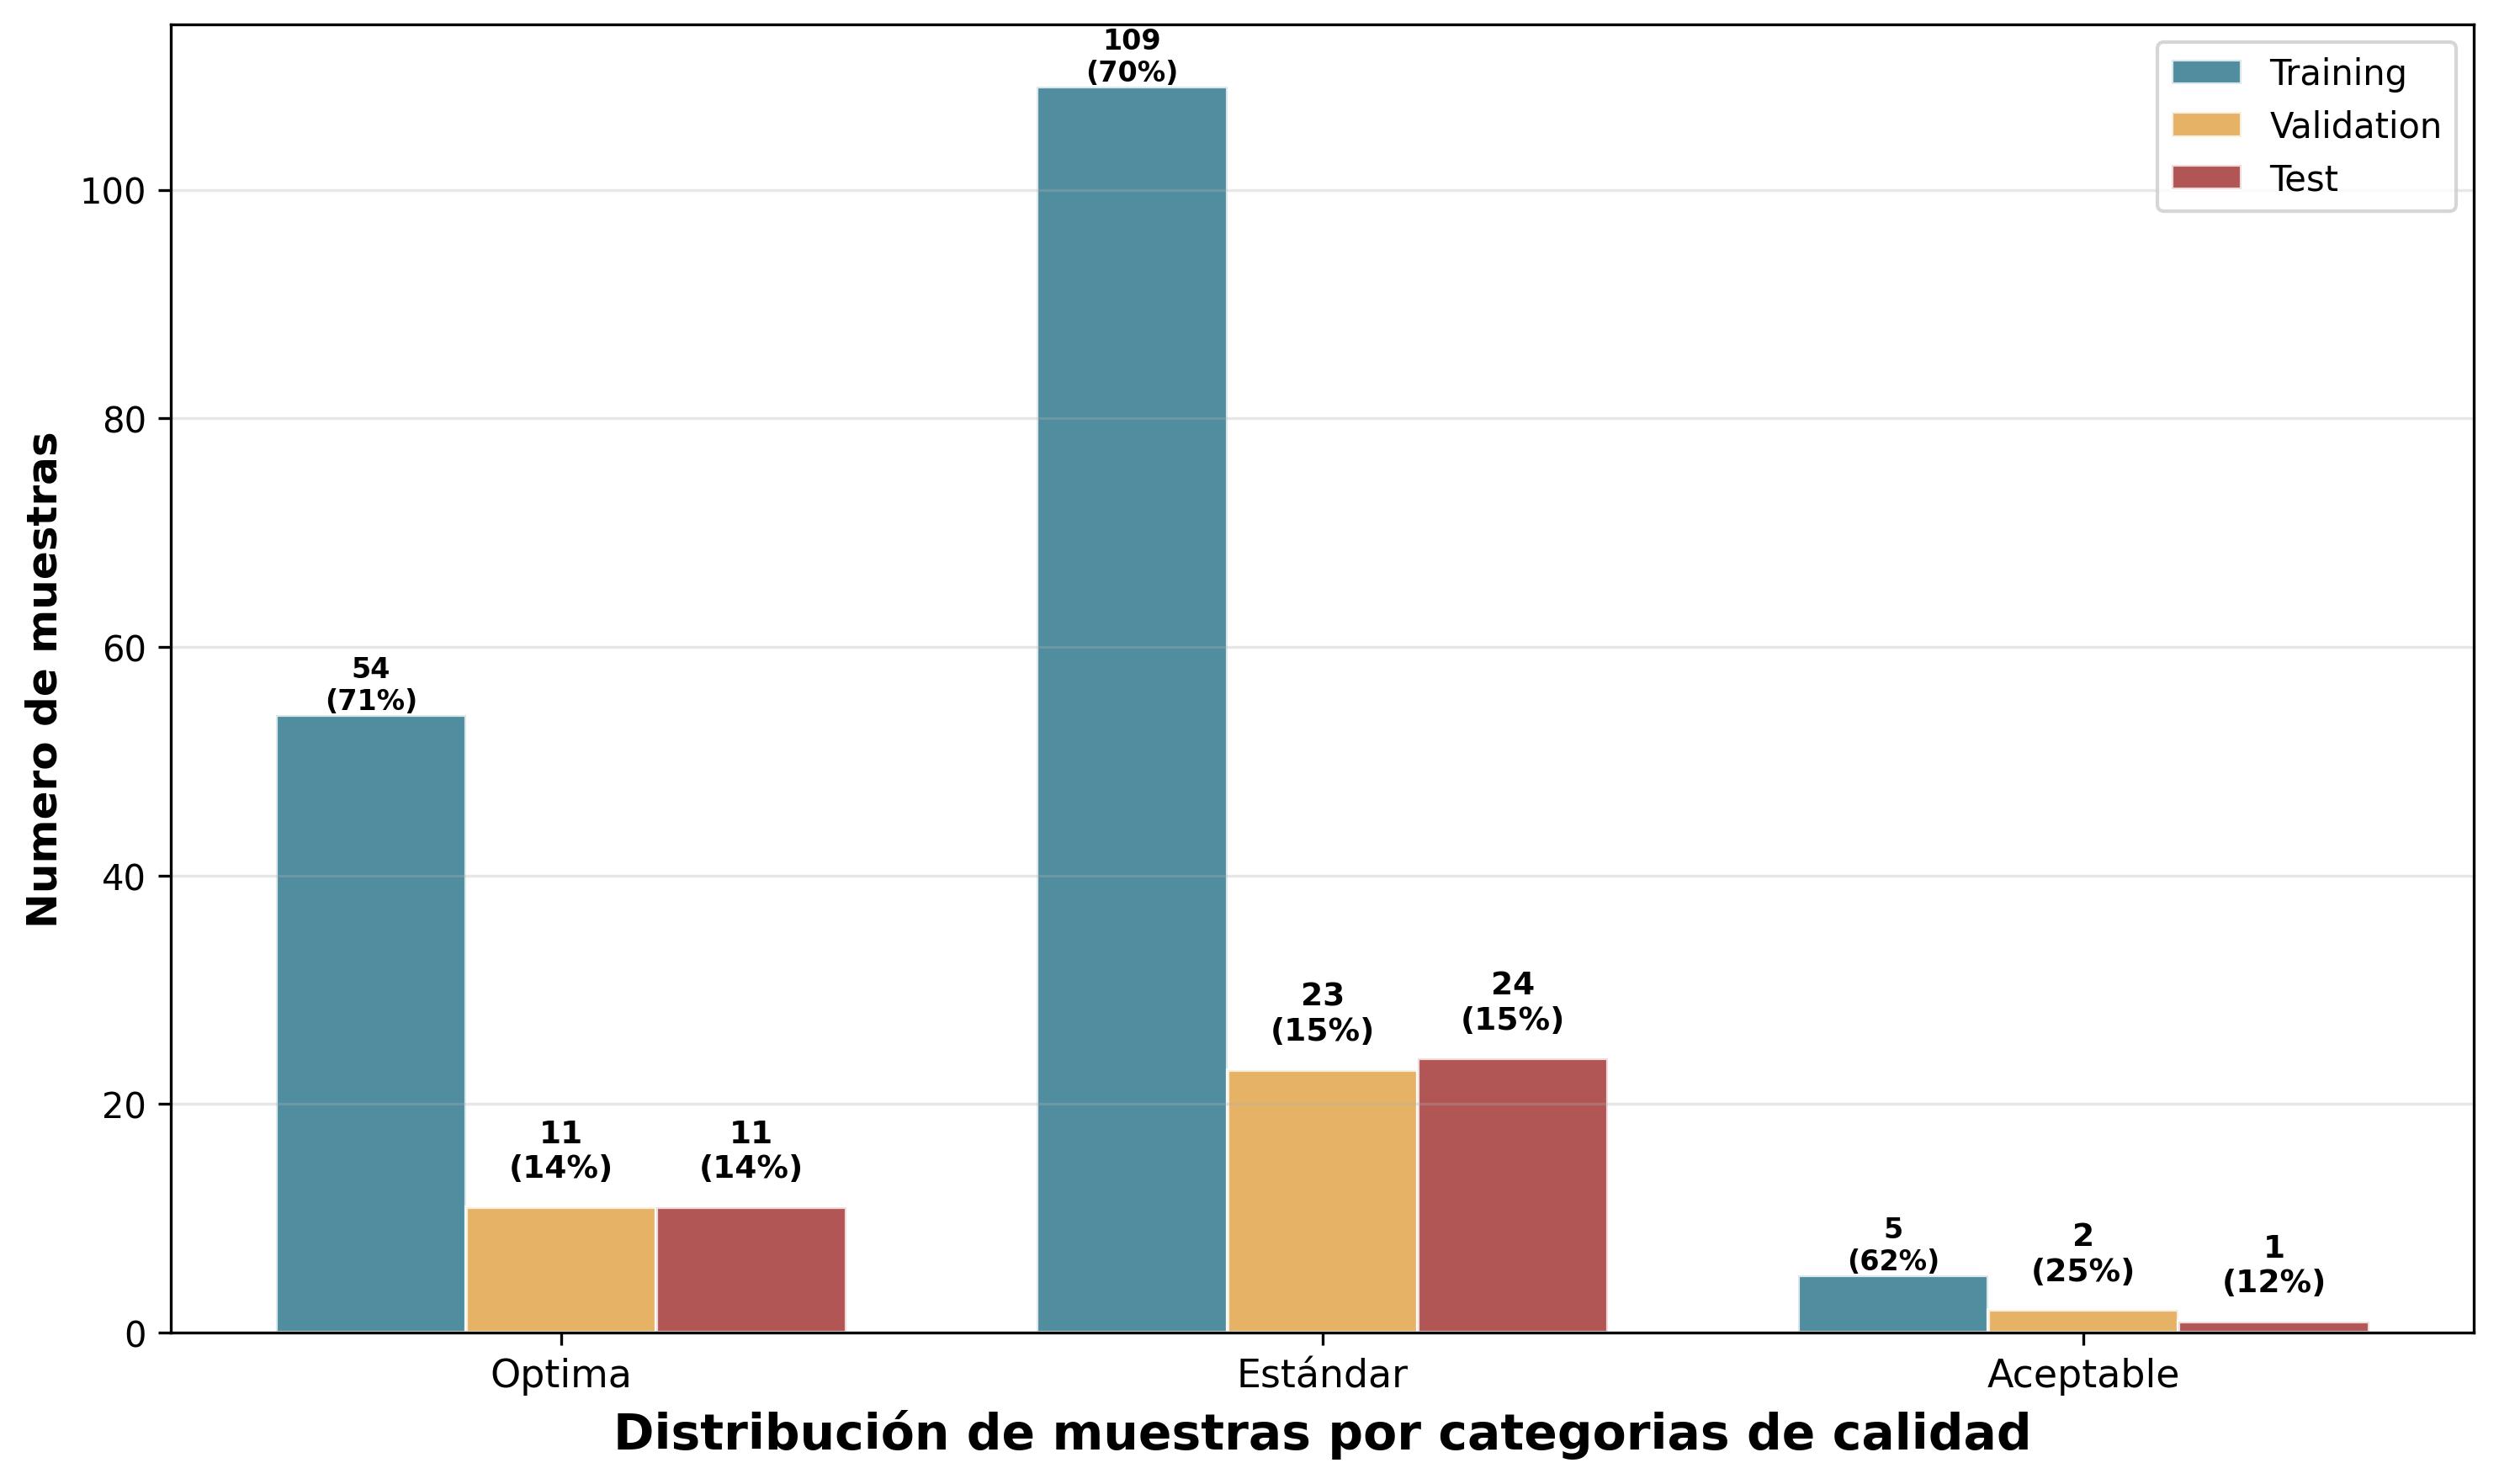

In [11]:
# Grafico a partir de categorias
tags = ['Optima', 'Estándar', 'Aceptable']

bars_train = [stats_train[cat]['count'] for cat in tags]
bars_val = [stats_val[cat]['count'] for cat in tags] 
bars_test = [stats_test[cat]['count'] for cat in tags]


# Configuración de grafico
barW = 0.25
r = np.arange(len(tags))
r2 = r + barW
r3 = r2 + barW

# crear grafico
fis, ax = plt.subplots(figsize=(10,6), dpi=300)

# Barras por cojunto
ax.bar(r, bars_train, color='#237187', width=barW, edgecolor='#ffffff', label='Training', alpha=0.8)
ax.bar(r2, bars_val, color='#e09f3e', width=barW, edgecolor='#ffffff', label='Validation', alpha=0.8)
ax.bar(r3, bars_test, color='#9e2a2b', width=barW, edgecolor='#ffffff', label='Test', alpha=0.8)

# Agregar valores + porcentaje
for i, (train, val, test) in enumerate(zip(bars_train, bars_val, bars_test)):
    total_categoria = train + val + test
    
    # Training
    if train > 0:
        porcentaje = (train / total_categoria) * 100
        ax.text(r[i], train , f'{train}\n({porcentaje:.0f}%)', 
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Validation
    if val > 0:
        porcentaje = (val / total_categoria) * 100
        ax.text(r2[i], val + 2, f'{val}\n({porcentaje:.0f}%)', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Test
    if test > 0:
        porcentaje = (test / total_categoria) * 100
        ax.text(r3[i], test + 2, f'{test}\n({porcentaje:.0f}%)', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
        
# Personalización de label del grafico
ax.set_xlabel('Categoria de calidad', fontweight='bold', fontsize=12)
ax.set_ylabel('Numero de muestras', fontweight='bold', fontsize=12)
ax.set_xlabel('Distribución de muestras por categorias de calidad', fontweight='bold', fontsize=14)

# Eje X
ax.set_xticks(r + barW)
ax.set_xticklabels(tags, fontsize=11)

# Leyenda
ax.legend()

# Añadir grid 
ax.grid(axis='y', alpha=0.3)

# Layaout
plt.tight_layout()
plt.show

In [12]:
print("Training")
for i, stats in stats_train.items():
    if stats['count'] > 0:
        print(f"{i}: {stats['count']} muestras, Mean: {stats['mean']:.3f}, rango: {stats['min']:.3f} - {stats['max']:.3f}")

print("\nValidation")
for i, stats in stats_val.items():
    if stats['count'] > 0:
        print(f"{i}: {stats['count']} muestras, Mean: {stats['mean']:.3f}, rango: {stats['min']:.3f} - {stats['max']:.3f}")

print("\nTest")
for i, stats in stats_test.items():
    if stats['count'] > 0:
        print(f"{i}: {stats['count']} muestras, Mean: {stats['mean']:.3f}, rango: {stats['min']:.3f} - {stats['max']:.3f}")

Training
Estándar: 109 muestras, Mean: 0.152, rango: 0.140 - 0.160
Aceptable: 5 muestras, Mean: 0.138, rango: 0.135 - 0.139
Optima: 54 muestras, Mean: 0.165, rango: 0.160 - 0.174

Validation
Estándar: 23 muestras, Mean: 0.152, rango: 0.141 - 0.159
Optima: 11 muestras, Mean: 0.164, rango: 0.161 - 0.171
Aceptable: 2 muestras, Mean: 0.137, rango: 0.136 - 0.139

Test
Optima: 11 muestras, Mean: 0.165, rango: 0.160 - 0.174
Estándar: 24 muestras, Mean: 0.151, rango: 0.140 - 0.160
Aceptable: 1 muestras, Mean: 0.135, rango: 0.135 - 0.135


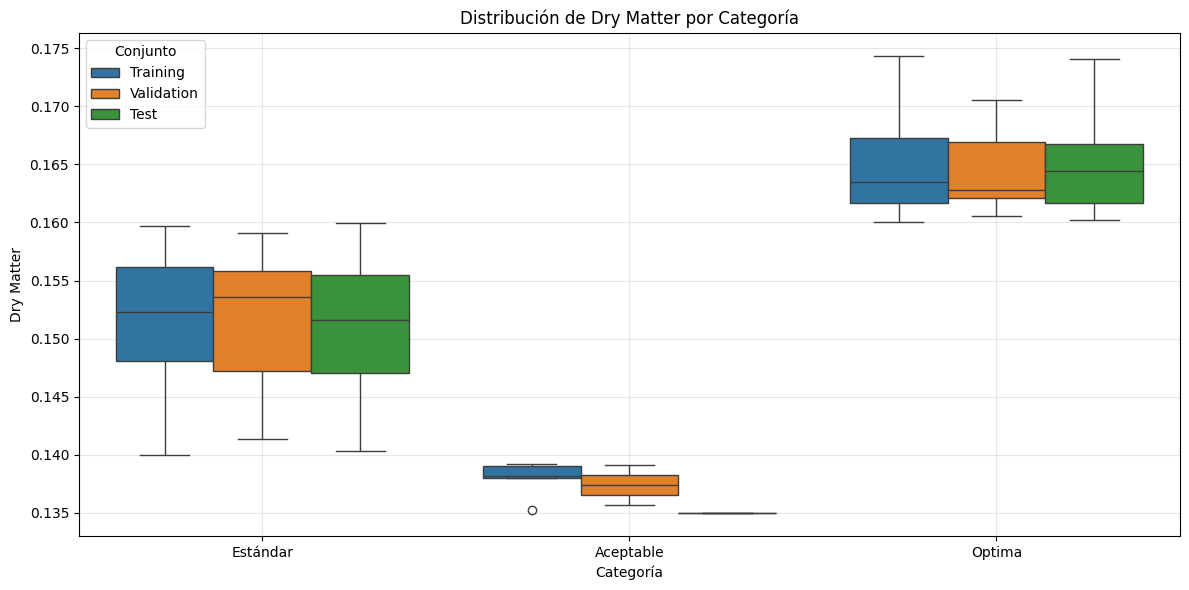

In [13]:
import seaborn as sns

def created_graph_boxplot(val_train, val_val, val_test):
    data_graph = []

    for x, val_dict in [('Training', valores_train), 
                       ('Validation', valores_val), 
                       ('Test', valores_test)]:
        for cat, val in val_dict.items():
            if len(val) > 0:
                for valor in val:
                    data_graph.append({ 'Conjunto': x, 'Categoría': cat, 'Dry Matter': valor})

    df_grafico = pd.DataFrame(data_graph)
    
    # Crear el gráfico
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_grafico, x='Categoría', y='Dry Matter', hue='Conjunto')
    plt.title('Distribución de Dry Matter por Categoría')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return df_grafico

df_boxplot = created_graph_boxplot(valores_train, valores_val, valores_test)

In [14]:
# Añadire el de histograma dependera del despues
# def histograma(Y_train_dry, Y_val_dry, Y_test_dry, Y_train, Y_val, Y_test):


In [15]:
print('\n' + '*'*5 + "Consistencia de rangos" + '*'*5)
print(f"Dry matter global: {dataset_df['Dry matter'].min():.2f} - {dataset_df['Dry matter'].max():.2f}")
print(f"Training Range: {Y_train_dry.min():.4f} - {Y_train_dry.max():.4f}")
print(f"Validation Range: {Y_val_dry.min():.4f} - {Y_val_dry.max():.4f}")
print(f"Test Range: {Y_test_dry.min():.4f} - {Y_test_dry.max():.4f}")


# Verificar proporciones
print('\n' + '*'*5 + "Proporciones" + '*'*5)
print(f"Training: {len(train_idx)/len(dataset_df):.1%} ({len(train_idx)} muestras)")
print(f"Validation: {len(val_idx)/len(dataset_df):.1%} ({len(val_idx)} muestras)")
print(f"Test: {len(test_idx)/len(dataset_df):.1%} ({len(test_idx)} muestras)")



*****Consistencia de rangos*****
Dry matter global: 0.13 - 0.17
Training Range: 0.1353 - 0.1743
Validation Range: 0.1356 - 0.1705
Test Range: 0.1350 - 0.1740

*****Proporciones*****
Training: 70.0% (168 muestras)
Validation: 15.0% (36 muestras)
Test: 15.0% (36 muestras)


# **IMPLEMENTACIÓN DE ARQUITECTURA**

## Convertir características (X) a tensores

In [16]:
spectral_bands = [col for col in X_train.columns if col not in ['Apple']] 

X_train_clean = X_train[spectral_bands]
X_val_clean = X_val[spectral_bands]
X_test_clean = X_test[spectral_bands]

# print(f"Columnas actuales: {X_train_clean.columns.to_list()}") #Revisar que solo esten las bandas

# Convertir las caracteristicas (x) a tensores 
X_train_tensor = torch.FloatTensor(X_train_clean.values)
X_val_tensor = torch.FloatTensor(X_val_clean.values)
X_test_tensor = torch.FloatTensor(X_test_clean.values)

# print(f"Tensores creados...")
# print(f"Tensores train: {X_train_tensor.shape}")
# print(f"Tensores val: {X_val_tensor.shape}")
# print(f"Tensores test: {X_test_tensor.shape}")


### Convertir etiquetas (Y) a tensores numéricos

In [17]:
# Codifican de string a int
label_encoder = LabelEncoder()

all_tags = np.unique(Y_train)
Y_encoded = label_encoder.fit_transform(all_tags)

# print(f"Mapping de categorais: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Aplicamos a los tres cojuntos de datos
Y_train_encoded = torch.LongTensor(label_encoder.transform(Y_train))
Y_val_encoded = torch.LongTensor(label_encoder.transform(Y_val))
Y_test_encoded = torch.LongTensor(label_encoder.transform(Y_test))


## Creación de dataloaders 

In [18]:
# crear dataset = empaquetador
train_dataset = TensorDataset(X_train_tensor, Y_train_encoded)
val_dataset = TensorDataset(X_val_tensor, Y_val_encoded)
test_dataset = TensorDataset(X_test_tensor, Y_test_encoded)

# Crear dataloader = repartidor de batches
batch_size = 32 #Voy a probar primero con este valor
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

In [28]:
print("🔍 DIAGNÓSTICO DE DATOS Y ETIQUETAS:")

# Verificar un batch de entrenamiento
data, target = next(iter(train_loader))
print(f"📊 Shape de datos: {data.shape}")  # Debería ser (batch, 141)
print(f"🎯 Shape de etiquetas: {target.shape}")
print(f"🔢 Valores únicos en etiquetas: {torch.unique(target)}")
print(f"📈 Rango de etiquetas: {target.min()} a {target.max()}")
print(f"📦 Tipo de etiquetas: {target.dtype}")

# Verificar distribución de clases
def verificar_distribucion(loader, nombre="Train"):
    todas_etiquetas = []
    for _, target in loader:
        todas_etiquetas.extend(target.numpy())
    
    unique, counts = np.unique(todas_etiquetas, return_counts=True)
    print(f"\n📋 DISTRIBUCIÓN {nombre}:")
    for clase, count in zip(unique, counts):
        print(f"  Clase {clase}: {count} muestras ({count/len(todas_etiquetas):.1%})")

verificar_distribucion(train_loader, "ENTRENAMIENTO")
verificar_distribucion(val_loader, "VALIDACIÓN")
verificar_distribucion(test_loader, "PRUEBA")

🔍 DIAGNÓSTICO DE DATOS Y ETIQUETAS:
📊 Shape de datos: torch.Size([32, 141])
🎯 Shape de etiquetas: torch.Size([32])
🔢 Valores únicos en etiquetas: tensor([1, 2])
📈 Rango de etiquetas: 1 a 2
📦 Tipo de etiquetas: torch.int64

📋 DISTRIBUCIÓN ENTRENAMIENTO:
  Clase 0: 5 muestras (3.0%)
  Clase 1: 109 muestras (64.9%)
  Clase 2: 54 muestras (32.1%)

📋 DISTRIBUCIÓN VALIDACIÓN:
  Clase 0: 2 muestras (5.6%)
  Clase 1: 23 muestras (63.9%)
  Clase 2: 11 muestras (30.6%)

📋 DISTRIBUCIÓN PRUEBA:
  Clase 0: 1 muestras (2.8%)
  Clase 1: 24 muestras (66.7%)
  Clase 2: 11 muestras (30.6%)


## Definición de la red neuronal

In [ ]:
# import torch.nn as nn
# import torch.nn.functional as F

# class MLP_Apple(nn.Module):
#     def __init__(self, input_size, hidden_layers, outputs_size, activation, output_activation=None, dropout_rate=0.0):

#         super(MLP_Apple, self).__init__()

#         self.input_size = input_size
#         self.hidden_layers = hidden_layers
#         self.output_size = outputs_size
#         self.activation_name = activation
#         self.dropout_rate = dropout_rate

#         # Construir capas
#         self.layers = nn.ModuleList()
#         layer_size = [input_size] + hidden_layers + [outputs_size]

#         # Crear capas fully connected
#         for i in range(len(layer_size) - 1):
#             self.layers.append(nn.Linear(layer_size[i], layer_size[i + 1]))
        
#         # Dropout 
#         self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

#         # Funcion de activación
#         self.activation_fn = self._get_activation(activation)  # Cambié el nombre
#         self.output_activation_fn = self._get_activation(output_activation) if output_activation else None

#         # Inicialización de pesos
#         self._initialize_weights()

#     def _get_activation(self, activation_name):
#         if activation_name == 'sigmoid':
#             return nn.Sigmoid()
#         elif activation_name == 'relu':
#             return nn.ReLU()
#         elif activation_name == 'tanh':
#             return nn.Tanh()
#         elif activation_name == 'leaky_relu':
#             return nn.LeakyReLU(0.1)
#         elif activation_name == 'none' or activation_name is None:
#             return nn.Identity()
#         else:
#             raise ValueError(f"Función de activación no soportada: {activation_name}")

#     def _initialize_weights(self):
#         for layer in self.layers:
#             if isinstance(layer, nn.Linear):
#                 nn.init.xavier_uniform_(layer.weight)
#                 nn.init.constant_(layer.bias, 0)
    
#     def forward(self, x):
#         for i in range(len(self.layers) - 1):
#             x = self.layers[i](x)
#             x = self.activation_fn(x)
#             if self.dropout:
#                 x = self.dropout(x)
        
#         x = self.layers[-1](x)
#         if self.output_activation:
#             x = self.output_activation(x)
        
#         return x
    
#     def get_architecture_info(self):
#         return {
#             'input_size': self.input_size,
#             'hidden_layers': self.hidden_layers,
#             'output_size': self.output_size,
#             'total_layers': len(self.layers),
#             'activation': self.activation_name,
#             'dropout_rate': self.dropout_rate
#         }   

import torch.nn as nn

class MLP_Apple(nn.Module):
    def __init__(self, input_size, hidden_layers, outputs_size, activation, output_activation=None, dropout_rate=0.0):
        super(MLP_Apple, self).__init__()

        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.output_size = outputs_size
        self.activation_name = activation
        self.dropout_rate = dropout_rate

        # Construir capas
        self.layers = nn.ModuleList()
        layer_sizes = [input_size] + hidden_layers + [outputs_size]

        # Crear capas fully connected
        for i in range(len(layer_sizes) - 1):
            self.layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
        
        # Dropout 
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

        # Funciones de activación - NOMBRES CONSISTENTES
        self.hidden_activation = self._get_activation(activation)
        self.output_activation = self._get_activation(output_activation) if output_activation else None

        # Inicialización de pesos
        self._initialize_weights()

    def _get_activation(self, activation_name):
        """Retorna instancias de las activaciones"""
        if activation_name == 'sigmoid':
            return nn.Sigmoid()
        elif activation_name == 'relu':
            return nn.ReLU()
        elif activation_name == 'tanh':
            return nn.Tanh()
        elif activation_name == 'leaky_relu':
            return nn.LeakyReLU(0.1)
        elif activation_name == 'none' or activation_name is None:
            return nn.Identity()
        else:
            raise ValueError(f"Función de activación no soportada: {activation_name}")

    def _initialize_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0)
    
    def forward(self, x):
        # Pasar por todas las capas excepto la última
        for i in range(len(self.layers) - 1):
            x = self.layers[i](x)
            x = self.hidden_activation(x)  # Usar hidden_activation
            if self.dropout:
                x = self.dropout(x)
        
        # Última capa
        x = self.layers[-1](x)
        if self.output_activation:  # Ahora output_activation existe
            x = self.output_activation(x)
        
        return x
    
    def get_architecture_info(self):
        """Retorna información de la arquitectura"""
        return {
            'input_size': self.input_size,
            'hidden_layers': self.hidden_layers,
            'output_size': self.output_size,
            'total_layers': len(self.layers),
            'activation': self.activation_name,
            'dropout_rate': self.dropout_rate
        }

## Clase trainer para entrenamiento

In [20]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# import pandas as pd
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, mean_squared_error, mean_absolute_error
# from sklearn.preprocessing import LabelEncoder

# class CompleteTrainer:
#     def __init__(self, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
#         self.model = model
#         self.device = device
#         self.model.to(self.device)
        
#         # Historial COMPLETO por época
#         self.history = {
#             'epoch': [],
#             # Loss
#             'train_loss': [], 'val_loss': [],
#             # Clasificación general
#             'train_accuracy': [], 'val_accuracy': [],
#             'val_precision_macro': [], 'val_recall_macro': [], 'val_f1_macro': [],
#             'val_precision_weighted': [], 'val_recall_weighted': [], 'val_f1_weighted': [],
#             # Regresión
#             'val_r2': [], 'val_rmse': [], 'val_mae': []
#         }
    
#     def setup_training(self, optimizer_name='adam', lr=0.001, criterion_name='mse', **optimizer_params):
#         """Configura TODO el entrenamiento de una vez"""
#         # Optimizador
#         if optimizer_name.lower() == 'adam':
#             self.optimizer = optim.Adam(self.model.parameters(), lr=lr, **optimizer_params)
#         elif optimizer_name.lower() == 'sgd':
#             self.optimizer = optim.SGD(self.model.parameters(), lr=lr, **optimizer_params)
#         elif optimizer_name.lower() == 'rmsprop':
#             self.optimizer = optim.RMSprop(self.model.parameters(), lr=lr, **optimizer_params)
#         else:
#             raise ValueError(f"Optimizador no soportado: {optimizer_name}")
        
#         # Función de pérdida - PARA REGRESIÓN
#         if criterion_name.lower() == 'mse':
#             self.criterion = nn.MSELoss()
#         elif criterion_name.lower() == 'bce':
#             self.criterion = nn.BCEWithLogitsLoss()
#         elif criterion_name.lower() == 'l1':
#             self.criterion = nn.L1Loss()
#         elif criterion_name.lower() == 'cross_entropy':
#             self.criterion = nn.CrossEntropyLoss()
#         else:
#             raise ValueError(f"Función de pérdida no soportada: {criterion_name}")
        
#         print(f"✅ Training configurado - Optim: {optimizer_name}, LR: {lr}, Loss: {criterion_name}")
    
#     def compute_detailed_metrics(self, y_true, y_pred):
#         """Calcula métricas detalladas para REGRESIÓN y CLASIFICACIÓN MULTICLASE"""
#         # Convertir a numpy
#         y_true_np = y_true.cpu().numpy() if torch.is_tensor(y_true) else y_true
#         y_pred_np = y_pred.cpu().numpy() if torch.is_tensor(y_pred) else y_pred
        
#         # Para clasificación multiclase, necesitamos discretizar las predicciones
#         # Asumiendo que tienes categorías como: 0=Óptimo, 1=Aceptable, 2=No aceptable, etc.
        
#         # Discretizar predicciones para clasificación
#         # Ajusta estos umbrales según tus categorías de calidad
#         y_pred_class = np.digitize(y_pred_np, bins=[0.33, 0.66])  # Ejemplo: 3 clases
        
#         # Asegurar que las clases estén en el rango correcto
#         y_pred_class = np.clip(y_pred_class, 0, 2)  # Para 3 clases: 0,1,2
        
#         metrics = {
#             # Métricas de CLASIFICACIÓN
#             'accuracy': accuracy_score(y_true_np, y_pred_class),
#             'precision_macro': precision_score(y_true_np, y_pred_class, average='macro', zero_division=0),
#             'recall_macro': recall_score(y_true_np, y_pred_class, average='macro', zero_division=0),
#             'f1_macro': f1_score(y_true_np, y_pred_class, average='macro', zero_division=0),
#             'precision_weighted': precision_score(y_true_np, y_pred_class, average='weighted', zero_division=0),
#             'recall_weighted': recall_score(y_true_np, y_pred_class, average='weighted', zero_division=0),
#             'f1_weighted': f1_score(y_true_np, y_pred_class, average='weighted', zero_division=0),
            
#             # Métricas de REGRESIÓN
#             'r2': r2_score(y_true_np, y_pred_np),
#             'rmse': np.sqrt(mean_squared_error(y_true_np, y_pred_np)),
#             'mae': mean_absolute_error(y_true_np, y_pred_np)
#         }
        
#         # Métricas por clase individual (si hay pocas clases)
#         unique_classes = np.unique(y_true_np)
#         if len(unique_classes) <= 5:  # Solo si hay pocas clases
#             precision_per_class = precision_score(y_true_np, y_pred_class, average=None, zero_division=0)
#             recall_per_class = recall_score(y_true_np, y_pred_class, average=None, zero_division=0)
            
#             for i, class_idx in enumerate(unique_classes):
#                 metrics[f'precision_class_{class_idx}'] = precision_per_class[i]
#                 metrics[f'recall_class_{class_idx}'] = recall_per_class[i]
        
#         return metrics
    
#     def train_epoch_with_metrics(self, train_loader):
#         """Entrena una época y retorna pérdida + métricas"""
#         self.model.train()
#         total_loss = 0
#         all_targets = []
#         all_predictions = []
#         batch_count = 0
        
#         for data, target in train_loader:
#             data, target = data.to(self.device), target.to(self.device)
            
#             # Asegurar formas correctas
#             if len(data.shape) > 2:
#                 data = data.view(data.size(0), -1)
            
#             self.optimizer.zero_grad()
#             output = self.model(data)
            
#             # Ajustar formas para la pérdida
#             output = output.squeeze()
#             target = target.float().squeeze()
            
#             loss = self.criterion(output, target)
#             loss.backward()
#             self.optimizer.step()
            
#             total_loss += loss.item()
#             all_targets.extend(target.cpu().detach().numpy())
#             all_predictions.extend(output.cpu().detach().numpy())
#             batch_count += 1
        
#         avg_loss = total_loss / batch_count if batch_count > 0 else 0.0
#         metrics = self.compute_detailed_metrics(np.array(all_targets), np.array(all_predictions))
        
#         return avg_loss, metrics
    
#     def validate_with_metrics(self, val_loader):
#         """Valida y retorna pérdida + métricas"""
#         self.model.eval()
#         total_loss = 0
#         all_targets = []
#         all_predictions = []
#         batch_count = 0
        
#         with torch.no_grad():
#             for data, target in val_loader:
#                 data, target = data.to(self.device), target.to(self.device)
                
#                 if len(data.shape) > 2:
#                     data = data.view(data.size(0), -1)
                
#                 output = self.model(data)
#                 output = output.squeeze()
#                 target = target.float().squeeze()
                
#                 loss = self.criterion(output, target)
#                 total_loss += loss.item()
#                 all_targets.extend(target.cpu().numpy())
#                 all_predictions.extend(output.cpu().numpy())
#                 batch_count += 1
        
#         avg_loss = total_loss / batch_count if batch_count > 0 else 0.0
#         metrics = self.compute_detailed_metrics(np.array(all_targets), np.array(all_predictions))
        
#         return avg_loss, metrics
    
#     def train(self, train_loader, val_loader, epochs=100, save_csv=True):
#         """Entrenamiento con tracking completo de métricas"""
#         print(f"🚀 Iniciando entrenamiento - {epochs} épocas")
#         print(f"   Dispositivo: {self.device}")
        
#         for epoch in range(epochs):
#             # Entrenar
#             train_loss, train_metrics = self.train_epoch_with_metrics(train_loader)
            
#             # Validar
#             val_loss, val_metrics = self.validate_with_metrics(val_loader)
            
#             # Guardar TODO en historial
#             self.history['epoch'].append(epoch)
#             self.history['train_loss'].append(train_loss)
#             self.history['val_loss'].append(val_loss)
#             self.history['train_accuracy'].append(train_metrics['accuracy'])
#             self.history['val_accuracy'].append(val_metrics['accuracy'])
#             self.history['val_precision_macro'].append(val_metrics['precision_macro'])
#             self.history['val_recall_macro'].append(val_metrics['recall_macro'])
#             self.history['val_f1_macro'].append(val_metrics['f1_macro'])
#             self.history['val_precision_weighted'].append(val_metrics['precision_weighted'])
#             self.history['val_recall_weighted'].append(val_metrics['recall_weighted'])
#             self.history['val_f1_weighted'].append(val_metrics['f1_weighted'])
#             self.history['val_r2'].append(val_metrics['r2'])
#             self.history['val_rmse'].append(val_metrics['rmse'])
#             self.history['val_mae'].append(val_metrics['mae'])
            
#             # Guardar métricas por clase si existen
#             for key in val_metrics:
#                 if key.startswith('precision_class_') or key.startswith('recall_class_'):
#                     if key not in self.history:
#                         self.history[key] = []
#                     self.history[key].append(val_metrics[key])
            
#             # Guardar en CSV cada 10 épocas
#             if save_csv and epoch % 10 == 0:
#                 self.save_metrics_to_csv()
            
#             # Print progreso
#             if epoch % 10 == 0:
#                 print(f'Época {epoch:3d}/{epochs} | '
#                       f'Train Loss: {train_loss:.4f} | '
#                       f'Val Loss: {val_loss:.4f} | '
#                       f'Val Acc: {val_metrics["accuracy"]:.4f} | '
#                       f'Val R²: {val_metrics["r2"]:.4f}')

# def save_metrics_to_csv(self, filename=None, include_timestamp=True):
#     """Guarda métricas a CSV con opciones flexibles"""
#     import pandas as pd
#     from datetime import datetime
    
#     # Nombre de archivo flexible
#     if filename is None:
#         timestamp = datetime.now().strftime("%Y%m%d_%H%M%S") if include_timestamp else ""
#         filename = f"metricas_entrenamiento{'_' + timestamp if timestamp else ''}.csv"
    
#     df = pd.DataFrame(self.history)
#     df.to_csv(filename, index=False)
#     print(f"✅ Métricas guardadas en: {filename}")
#     return filename

# def plot_training_curves(self, save_path=None, show_plots=True, figsize=(15, 10)):
#     """Genera gráficas con opciones flexibles"""
#     import matplotlib.pyplot as plt
#     from datetime import datetime
    
#     # Ruta flexible para guardar
#     if save_path is None:
#         timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#         save_path = f"graficas_entrenamiento_{timestamp}.png"
    
#     fig, axes = plt.subplots(2, 2, figsize=figsize)
    
#     # Gráfica 1: Loss
#     axes[0,0].plot(self.history['train_loss'], label='Train Loss', color='blue', linewidth=2)
#     axes[0,0].plot(self.history['val_loss'], label='Val Loss', color='red', linewidth=2)
#     axes[0,0].set_title('Pérdida durante Entrenamiento', fontsize=14, fontweight='bold')
#     axes[0,0].set_xlabel('Época')
#     axes[0,0].set_ylabel('Pérdida')
#     axes[0,0].legend()
#     axes[0,0].grid(True, alpha=0.3)
    
#     # Gráfica 2: Accuracy
#     axes[0,1].plot(self.history['train_accuracy'], label='Train Accuracy', color='blue', linewidth=2)
#     axes[0,1].plot(self.history['val_accuracy'], label='Val Accuracy', color='red', linewidth=2)
#     axes[0,1].set_title('Accuracy durante Entrenamiento', fontsize=14, fontweight='bold')
#     axes[0,1].set_xlabel('Época')
#     axes[0,1].set_ylabel('Accuracy')
#     axes[0,1].legend()
#     axes[0,1].grid(True, alpha=0.3)
    
#     # Gráfica 3: Métricas de clasificación (macro)
#     axes[1,0].plot(self.history['val_precision_macro'], label='Precision Macro', color='green', linewidth=2)
#     axes[1,0].plot(self.history['val_recall_macro'], label='Recall Macro', color='orange', linewidth=2)
#     axes[1,0].plot(self.history['val_f1_macro'], label='F1 Macro', color='purple', linewidth=2)
#     axes[1,0].set_title('Métricas de Clasificación (Macro)', fontsize=14, fontweight='bold')
#     axes[1,0].set_xlabel('Época')
#     axes[1,0].set_ylabel('Score')
#     axes[1,0].legend()
#     axes[1,0].grid(True, alpha=0.3)
    
#     # Gráfica 4: Métricas de regresión
#     axes[1,1].plot(self.history['val_r2'], label='R²', color='red', linewidth=2)
#     axes[1,1].plot(self.history['val_rmse'], label='RMSE', color='blue', linewidth=2)
#     axes[1,1].plot(self.history['val_mae'], label='MAE', color='green', linewidth=2)
#     axes[1,1].set_title('Métricas de Regresión', fontsize=14, fontweight='bold')
#     axes[1,1].set_xlabel('Época')
#     axes[1,1].set_ylabel('Valor')
#     axes[1,1].legend()
#     axes[1,1].grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
#     if show_plots:
#         plt.show()
#     else:
#         plt.close()  # Cierra la figura si no se muestra
    
#     print(f"✅ Gráficas guardadas en: {save_path}")
#     return save_path

# def generate_complete_report(self, experiment_name="modelo_propuesto", output_dir="resultados"):
#     """Genera un reporte completo organizado"""
#     import os
#     import pandas as pd
    
#     # Crear directorio de resultados
#     os.makedirs(output_dir, exist_ok=True)
    
#     # Guardar métricas
#     csv_path = os.path.join(output_dir, f"{experiment_name}_metricas.csv")
#     self.save_metrics_to_csv(csv_path, include_timestamp=False)
    
#     # Generar gráficas
#     img_path = os.path.join(output_dir, f"{experiment_name}_graficas.png")
#     self.plot_training_curves(img_path, show_plots=True)
    
#     # Generar resumen ejecutivo
#     summary_path = os.path.join(output_dir, f"{experiment_name}_resumen.txt")
#     self.generate_summary(summary_path, experiment_name)
    
#     print(f"📊 Reporte completo generado en: {output_dir}/")
#     return {
#         'csv': csv_path,
#         'images': img_path,
#         'summary': summary_path
#     }

# def generate_summary(self, filepath, experiment_name):
#     """Genera un resumen ejecutivo del entrenamiento"""
#     with open(filepath, 'w') as f:
#         f.write(f"RESUMEN DEL ENTRENAMIENTO - {experiment_name}\n")
#         f.write("=" * 50 + "\n\n")
        
#         # Información básica
#         f.write("INFORMACIÓN DEL MODELO:\n")
#         f.write(f"- Épocas entrenadas: {len(self.history['epoch'])}\n")
#         f.write(f"- Mejor época: {np.argmin(self.history['val_loss'])}\n\n")
        
#         # Métricas finales
#         f.write("MÉTRICAS FINALES:\n")
#         f.write(f"- Loss Validación: {self.history['val_loss'][-1]:.4f}\n")
#         f.write(f"- Accuracy Validación: {self.history['val_accuracy'][-1]:.4f}\n")
#         f.write(f"- R² Validación: {self.history['val_r2'][-1]:.4f}\n")
#         f.write(f"- RMSE Validación: {self.history['val_rmse'][-1]:.4f}\n")
#         f.write(f"- F1-Score Macro: {self.history['val_f1_macro'][-1]:.4f}\n\n")
        
#         # Análisis de sobreajuste
#         overfitting_ratio = self.history['val_loss'][-1] / self.history['train_loss'][-1]
#         f.write("ANÁLISIS DE SOBREAJUSTE:\n")
#         f.write(f"- Ratio Val/Train Loss: {overfitting_ratio:.2f}\n")
#         if overfitting_ratio > 1.2:
#             f.write("- ⚠️  Posible sobreajuste detectado\n")
#         else:
#             f.write("- ✅ Buen balance entre train y validation\n")        
#         # # Guardar CSV final
#         # if save_csv:
#         #     self.save_metrics_to_csv()
        
#         # print("✅ Entrenamiento completado!")
#         # return self.history
    
#     # def save_metrics_to_csv(self, filename="metricas_entrenamiento.csv"):
#     #     """Guarda todas las métricas a CSV"""
#     #     df = pd.DataFrame(self.history)
#     #     df.to_csv(filename, index=False)
#     #     print(f"✅ Métricas guardadas en: {filename}")
    
#     # def plot_training_curves(self, save_path="graficas_entrenamiento.png"):
#     #     """Genera gráficas de pérdida y accuracy"""
#     #     import matplotlib.pyplot as plt
        
#     #     fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
#     #     # Gráfica 1: Loss
#     #     axes[0,0].plot(self.history['train_loss'], label='Train Loss', color='blue', linewidth=2)
#     #     axes[0,0].plot(self.history['val_loss'], label='Val Loss', color='red', linewidth=2)
#     #     axes[0,0].set_title('Pérdida durante Entrenamiento', fontsize=14, fontweight='bold')
#     #     axes[0,0].set_xlabel('Época')
#     #     axes[0,0].set_ylabel('Pérdida')
#     #     axes[0,0].legend()
#     #     axes[0,0].grid(True, alpha=0.3)
        
#     #     # Gráfica 2: Accuracy
#     #     axes[0,1].plot(self.history['train_accuracy'], label='Train Accuracy', color='blue', linewidth=2)
#     #     axes[0,1].plot(self.history['val_accuracy'], label='Val Accuracy', color='red', linewidth=2)
#     #     axes[0,1].set_title('Accuracy durante Entrenamiento', fontsize=14, fontweight='bold')
#     #     axes[0,1].set_xlabel('Época')
#     #     axes[0,1].set_ylabel('Accuracy')
#     #     axes[0,1].legend()
#     #     axes[0,1].grid(True, alpha=0.3)
        
#     #     # Gráfica 3: Métricas de clasificación (macro)
#     #     axes[1,0].plot(self.history['val_precision_macro'], label='Precision Macro', color='green', linewidth=2)
#     #     axes[1,0].plot(self.history['val_recall_macro'], label='Recall Macro', color='orange', linewidth=2)
#     #     axes[1,0].plot(self.history['val_f1_macro'], label='F1 Macro', color='purple', linewidth=2)
#     #     axes[1,0].set_title('Métricas de Clasificación (Macro)', fontsize=14, fontweight='bold')
#     #     axes[1,0].set_xlabel('Época')
#     #     axes[1,0].set_ylabel('Score')
#     #     axes[1,0].legend()
#     #     axes[1,0].grid(True, alpha=0.3)
        
#     #     # Gráfica 4: Métricas de regresión
#     #     axes[1,1].plot(self.history['val_r2'], label='R²', color='red', linewidth=2)
#     #     axes[1,1].plot(self.history['val_rmse'], label='RMSE', color='blue', linewidth=2)
#     #     axes[1,1].plot(self.history['val_mae'], label='MAE', color='green', linewidth=2)
#     #     axes[1,1].set_title('Métricas de Regresión', fontsize=14, fontweight='bold')
#     #     axes[1,1].set_xlabel('Época')
#     #     axes[1,1].set_ylabel('Valor')
#     #     axes[1,1].legend()
#     #     axes[1,1].grid(True, alpha=0.3)
        
#     #     plt.tight_layout()
#     #     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     #     plt.show()
#     #     print(f"✅ Gráficas guardadas en: {save_path}")

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import os
from datetime import datetime
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, mean_squared_error, mean_absolute_error

class CompleteTrainer:
    def __init__(self, model, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model
        self.device = device
        self.model.to(self.device)
        
        # Historial COMPLETO por época
        self.history = {
            'epoch': [],
            # Loss
            'train_loss': [], 'val_loss': [],
            # Clasificación general
            'train_accuracy': [], 'val_accuracy': [],
            'val_precision_macro': [], 'val_recall_macro': [], 'val_f1_macro': [],
            'val_precision_weighted': [], 'val_recall_weighted': [], 'val_f1_weighted': [],
            # Regresión
            'val_r2': [], 'val_rmse': [], 'val_mae': []
        }
    
    def setup_training(self, optimizer_name='adam', lr=0.001, criterion_name='mse', **optimizer_params):
        """Configura TODO el entrenamiento de una vez"""
        # Optimizador
        if optimizer_name.lower() == 'adam':
            self.optimizer = optim.Adam(self.model.parameters(), lr=lr, **optimizer_params)
        elif optimizer_name.lower() == 'sgd':
            self.optimizer = optim.SGD(self.model.parameters(), lr=lr, **optimizer_params)
        elif optimizer_name.lower() == 'rmsprop':
            self.optimizer = optim.RMSprop(self.model.parameters(), lr=lr, **optimizer_params)
        else:
            raise ValueError(f"Optimizador no soportado: {optimizer_name}")
        
        # Función de pérdida - PARA REGRESIÓN
        if criterion_name.lower() == 'mse':
            self.criterion = nn.MSELoss()
        elif criterion_name.lower() == 'bce':
            self.criterion = nn.BCEWithLogitsLoss()
        elif criterion_name.lower() == 'l1':
            self.criterion = nn.L1Loss()
        elif criterion_name.lower() == 'cross_entropy':
            self.criterion = nn.CrossEntropyLoss()
        else:
            raise ValueError(f"Función de pérdida no soportada: {criterion_name}")
        
        print(f"✅ Training configurado - Optim: {optimizer_name}, LR: {lr}, Loss: {criterion_name}")
    
    def compute_detailed_metrics(self, y_true, y_pred):
        """Calcula métricas detalladas para REGRESIÓN y CLASIFICACIÓN MULTICLASE"""
        # Convertir a numpy
        y_true_np = y_true.cpu().numpy() if torch.is_tensor(y_true) else y_true
        y_pred_np = y_pred.cpu().numpy() if torch.is_tensor(y_pred) else y_pred
        
        # Para clasificación multiclase, necesitamos discretizar las predicciones
        # Asumiendo que tienes categorías como: 0=Óptimo, 1=Aceptable, 2=No aceptable, etc.
        
        # Discretizar predicciones para clasificación
        # Ajusta estos umbrales según tus categorías de calidad
        y_pred_class = np.digitize(y_pred_np, bins=[0.33, 0.66])  # Ejemplo: 3 clases
        
        # Asegurar que las clases estén en el rango correcto
        y_pred_class = np.clip(y_pred_class, 0, 2)  # Para 3 clases: 0,1,2
        
        metrics = {
            # Métricas de CLASIFICACIÓN
            'accuracy': accuracy_score(y_true_np, y_pred_class),
            'precision_macro': precision_score(y_true_np, y_pred_class, average='macro', zero_division=0),
            'recall_macro': recall_score(y_true_np, y_pred_class, average='macro', zero_division=0),
            'f1_macro': f1_score(y_true_np, y_pred_class, average='macro', zero_division=0),
            'precision_weighted': precision_score(y_true_np, y_pred_class, average='weighted', zero_division=0),
            'recall_weighted': recall_score(y_true_np, y_pred_class, average='weighted', zero_division=0),
            'f1_weighted': f1_score(y_true_np, y_pred_class, average='weighted', zero_division=0),
            
            # Métricas de REGRESIÓN
            'r2': r2_score(y_true_np, y_pred_np),
            'rmse': np.sqrt(mean_squared_error(y_true_np, y_pred_np)),
            'mae': mean_absolute_error(y_true_np, y_pred_np)
        }
        
        # Métricas por clase individual (si hay pocas clases)
        unique_classes = np.unique(y_true_np)
        if len(unique_classes) <= 5:  # Solo si hay pocas clases
            precision_per_class = precision_score(y_true_np, y_pred_class, average=None, zero_division=0)
            recall_per_class = recall_score(y_true_np, y_pred_class, average=None, zero_division=0)
            
            for i, class_idx in enumerate(unique_classes):
                metrics[f'precision_class_{class_idx}'] = precision_per_class[i]
                metrics[f'recall_class_{class_idx}'] = recall_per_class[i]
        
        return metrics
    
    def train_epoch_with_metrics(self, train_loader):
        """Entrena una época y retorna pérdida + métricas"""
        self.model.train()
        total_loss = 0
        all_targets = []
        all_predictions = []
        batch_count = 0
        
        for data, target in train_loader:
            data, target = data.to(self.device), target.to(self.device)
            
            # Asegurar formas correctas
            if len(data.shape) > 2:
                data = data.view(data.size(0), -1)
            
            self.optimizer.zero_grad()
            output = self.model(data)
            
            # Ajustar formas para la pérdida
            output = output.squeeze()
            target = target.float().squeeze()
            
            loss = self.criterion(output, target)
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            all_targets.extend(target.cpu().detach().numpy())
            all_predictions.extend(output.cpu().detach().numpy())
            batch_count += 1
        
        avg_loss = total_loss / batch_count if batch_count > 0 else 0.0
        metrics = self.compute_detailed_metrics(np.array(all_targets), np.array(all_predictions))
        
        return avg_loss, metrics
    
    def validate_with_metrics(self, val_loader):
        """Valida y retorna pérdida + métricas"""
        self.model.eval()
        total_loss = 0
        all_targets = []
        all_predictions = []
        batch_count = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(self.device), target.to(self.device)
                
                if len(data.shape) > 2:
                    data = data.view(data.size(0), -1)
                
                output = self.model(data)
                output = output.squeeze()
                target = target.float().squeeze()
                
                loss = self.criterion(output, target)
                total_loss += loss.item()
                all_targets.extend(target.cpu().numpy())
                all_predictions.extend(output.cpu().numpy())
                batch_count += 1
        
        avg_loss = total_loss / batch_count if batch_count > 0 else 0.0
        metrics = self.compute_detailed_metrics(np.array(all_targets), np.array(all_predictions))
        
        return avg_loss, metrics
    
    def train(self, train_loader, val_loader, epochs=100, save_csv=True):
        """Entrenamiento con tracking completo de métricas"""
        print(f"🚀 Iniciando entrenamiento - {epochs} épocas")
        print(f"   Dispositivo: {self.device}")
        
        for epoch in range(epochs):
            # Entrenar
            train_loss, train_metrics = self.train_epoch_with_metrics(train_loader)
            
            # Validar
            val_loss, val_metrics = self.validate_with_metrics(val_loader)
            
            # Guardar TODO en historial
            self.history['epoch'].append(epoch)
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_accuracy'].append(train_metrics['accuracy'])
            self.history['val_accuracy'].append(val_metrics['accuracy'])
            self.history['val_precision_macro'].append(val_metrics['precision_macro'])
            self.history['val_recall_macro'].append(val_metrics['recall_macro'])
            self.history['val_f1_macro'].append(val_metrics['f1_macro'])
            self.history['val_precision_weighted'].append(val_metrics['precision_weighted'])
            self.history['val_recall_weighted'].append(val_metrics['recall_weighted'])
            self.history['val_f1_weighted'].append(val_metrics['f1_weighted'])
            self.history['val_r2'].append(val_metrics['r2'])
            self.history['val_rmse'].append(val_metrics['rmse'])
            self.history['val_mae'].append(val_metrics['mae'])
            
            # Guardar métricas por clase si existen
            for key in val_metrics:
                if key.startswith('precision_class_') or key.startswith('recall_class_'):
                    if key not in self.history:
                        self.history[key] = []
                    self.history[key].append(val_metrics[key])
            
            # Guardar en CSV cada 10 épocas
            if save_csv and epoch % 10 == 0:
                self.save_metrics_to_csv()
            
            # Print progreso
            if epoch % 10 == 0:
                print(f'Época {epoch:3d}/{epochs} | '
                      f'Train Loss: {train_loss:.4f} | '
                      f'Val Loss: {val_loss:.4f} | '
                      f'Val Acc: {val_metrics["accuracy"]:.4f} | '
                      f'Val R²: {val_metrics["r2"]:.4f}')
        
        # Guardar CSV final
        if save_csv:
            self.save_metrics_to_csv()
        
        print("✅ Entrenamiento completado!")
        return self.history

    # === NUEVAS FUNCIONES MEJORADAS ===
    
    def save_metrics_to_csv(self, filename=None, include_timestamp=True):
        """Guarda métricas a CSV con opciones flexibles"""
        # Nombre de archivo flexible
        if filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S") if include_timestamp else ""
            filename = f"metricas_entrenamiento{'_' + timestamp if timestamp else ''}.csv"
        
        df = pd.DataFrame(self.history)
        df.to_csv(filename, index=False)
        print(f"✅ Métricas guardadas en: {filename}")
        return filename
    
    def plot_training_curves(self, save_path=None, show_plots=True, figsize=(15, 10)):
        """Genera gráficas con opciones flexibles"""
        import matplotlib.pyplot as plt
        
        # Ruta flexible para guardar
        if save_path is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            save_path = f"graficas_entrenamiento_{timestamp}.png"
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        # Gráfica 1: Loss
        axes[0,0].plot(self.history['train_loss'], label='Train Loss', color='blue', linewidth=2)
        axes[0,0].plot(self.history['val_loss'], label='Val Loss', color='red', linewidth=2)
        axes[0,0].set_title('Pérdida durante Entrenamiento', fontsize=14, fontweight='bold')
        axes[0,0].set_xlabel('Época')
        axes[0,0].set_ylabel('Pérdida')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Gráfica 2: Accuracy
        axes[0,1].plot(self.history['train_accuracy'], label='Train Accuracy', color='blue', linewidth=2)
        axes[0,1].plot(self.history['val_accuracy'], label='Val Accuracy', color='red', linewidth=2)
        axes[0,1].set_title('Accuracy durante Entrenamiento', fontsize=14, fontweight='bold')
        axes[0,1].set_xlabel('Época')
        axes[0,1].set_ylabel('Accuracy')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # Gráfica 3: Métricas de clasificación (macro)
        axes[1,0].plot(self.history['val_precision_macro'], label='Precision Macro', color='green', linewidth=2)
        axes[1,0].plot(self.history['val_recall_macro'], label='Recall Macro', color='orange', linewidth=2)
        axes[1,0].plot(self.history['val_f1_macro'], label='F1 Macro', color='purple', linewidth=2)
        axes[1,0].set_title('Métricas de Clasificación (Macro)', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Época')
        axes[1,0].set_ylabel('Score')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Gráfica 4: Métricas de regresión
        axes[1,1].plot(self.history['val_r2'], label='R²', color='red', linewidth=2)
        axes[1,1].plot(self.history['val_rmse'], label='RMSE', color='blue', linewidth=2)
        axes[1,1].plot(self.history['val_mae'], label='MAE', color='green', linewidth=2)
        axes[1,1].set_title('Métricas de Regresión', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Época')
        axes[1,1].set_ylabel('Valor')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        if show_plots:
            plt.show()
        else:
            plt.close()  # Cierra la figura si no se muestra
        
        print(f"✅ Gráficas guardadas en: {save_path}")
        return save_path
    
    def generate_complete_report(self, experiment_name="modelo_propuesto", output_dir="resultados"):
        """Genera un reporte completo organizado"""
        # Crear directorio de resultados
        os.makedirs(output_dir, exist_ok=True)
        
        # Guardar métricas
        csv_path = os.path.join(output_dir, f"{experiment_name}_metricas.csv")
        self.save_metrics_to_csv(csv_path, include_timestamp=False)
        
        # Generar gráficas
        img_path = os.path.join(output_dir, f"{experiment_name}_graficas.png")
        self.plot_training_curves(img_path, show_plots=True)
        
        # Generar resumen ejecutivo
        summary_path = os.path.join(output_dir, f"{experiment_name}_resumen.txt")
        self._generate_summary(summary_path, experiment_name)
        
        print(f"📊 Reporte completo generado en: {output_dir}/")
        return {
            'csv': csv_path,
            'images': img_path,
            'summary': summary_path
        }
    
    def _generate_summary(self, filepath, experiment_name):
        """Genera un resumen ejecutivo del entrenamiento (método interno)"""
        with open(filepath, 'w') as f:
            f.write(f"RESUMEN DEL ENTRENAMIENTO - {experiment_name}\n")
            f.write("=" * 50 + "\n\n")
            
            # Información básica
            f.write("INFORMACIÓN DEL MODELO:\n")
            f.write(f"- Épocas entrenadas: {len(self.history['epoch'])}\n")
            f.write(f"- Mejor época: {np.argmin(self.history['val_loss'])}\n\n")
            
            # Métricas finales
            f.write("MÉTRICAS FINALES:\n")
            f.write(f"- Loss Validación: {self.history['val_loss'][-1]:.4f}\n")
            f.write(f"- Accuracy Validación: {self.history['val_accuracy'][-1]:.4f}\n")
            f.write(f"- R² Validación: {self.history['val_r2'][-1]:.4f}\n")
            f.write(f"- RMSE Validación: {self.history['val_rmse'][-1]:.4f}\n")
            f.write(f"- F1-Score Macro: {self.history['val_f1_macro'][-1]:.4f}\n\n")
            
            # Análisis de sobreajuste
            overfitting_ratio = self.history['val_loss'][-1] / self.history['train_loss'][-1]
            f.write("ANÁLISIS DE SOBREAJUSTE:\n")
            f.write(f"- Ratio Val/Train Loss: {overfitting_ratio:.2f}\n")
            if overfitting_ratio > 1.2:
                f.write("- ⚠️  Posible sobreajuste detectado\n")
            else:
                f.write("- ✅ Buen balance entre train y validation\n")

    def generate_confusion_matrix(self, data_loader, normalize=True):
        """Genera y muestra matriz de confusión"""
        from sklearn.metrics import confusion_matrix
        import seaborn as sns
        import matplotlib.pyplot as plt
        
        self.model.eval()
        all_targets = []
        all_predictions = []
        
        with torch.no_grad():
            for data, target in data_loader:
                data, target = data.to(self.device), target.to(self.device)
                
                if len(data.shape) > 2:
                    data = data.view(data.size(0), -1)
                
                output = self.model(data)
                output = output.squeeze()
                
                # Convertir a numpy
                targets_np = target.cpu().numpy()
                predictions_np = output.cpu().numpy()
                
                # Discretizar predicciones (igual que en compute_detailed_metrics)
                predictions_class = np.digitize(predictions_np, bins=[0.33, 0.66])
                predictions_class = np.clip(predictions_class, 0, 2)
                
                all_targets.extend(targets_np)
                all_predictions.extend(predictions_class)
        
        # Calcular matriz de confusión
        cm = confusion_matrix(all_targets, all_predictions)
        
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Visualizar
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', 
                    cmap='Blues', cbar=True,
                    xticklabels=['Optima', 'Estándar', 'Aceptable'],
                    yticklabels=['Optima', 'Estándar', 'Aceptable'])
        
        plt.title('Matriz de Confusión' + (' (Normalizada)' if normalize else ''))
        plt.xlabel('Predicción')
        plt.ylabel('Valor Real')
        plt.tight_layout()
        plt.show()
        
        return cm

    def analyze_errors_by_class(self, data_loader):
        """Analiza errores por categoría de calidad"""
        cm = self.generate_confusion_matrix(data_loader, normalize=False)
        
        print("\n🔍 ANÁLISIS DE ERRORES POR CLASE:")
        print("=" * 50)
        
        # Asumiendo clases: 0=Óptimo, 1=Aceptable, 2=No Aceptable
        class_names = ['Optima', 'Estándar', 'Aceptable']
        
        for i, class_name in enumerate(class_names):
            total_real = cm[i].sum()
            correct = cm[i, i]
            accuracy_class = correct / total_real if total_real > 0 else 0
            
            print(f"\n📊 CLASE: {class_name}")
            print(f"  - Total muestras: {total_real}")
            print(f"  - Correctas: {correct}")
            print(f"  - Accuracy: {accuracy_class:.2%}")
            
            # Mostrar confusiones
            for j, pred_name in enumerate(class_names):
                if i != j and cm[i, j] > 0:
                    print(f"  - Se confunde con {pred_name}: {cm[i, j]} muestras ({cm[i, j]/total_real:.1%})")

    def validate_with_metrics(self, val_loader):
        """Valida y retorna pérdida + métricas"""
        self.model.eval()
        total_loss = 0
        all_targets = []
        all_predictions = []
        batch_count = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(self.device), target.to(self.device)
                
                if len(data.shape) > 2:
                    data = data.view(data.size(0), -1)
                
                output = self.model(data)
                output = output.squeeze()
                target = target.float().squeeze()
                
                loss = self.criterion(output, target)
                total_loss += loss.item()
                all_targets.extend(target.cpu().numpy())
                all_predictions.extend(output.cpu().numpy())
                batch_count += 1
        
        avg_loss = total_loss / batch_count if batch_count > 0 else 0.0
        metrics = self.compute_detailed_metrics(np.array(all_targets), np.array(all_predictions))
        
        return avg_loss, metrics



ACTIVIDAD 4.1 - VALIDACIÓN CON DATOS DE PRUEBA
📊 MÉTRICAS FINALES EN TEST:
  - Loss: 0.1749
  - Accuracy: 0.3056
  - R²: -0.1064
  - F1-Score: 0.1560
  - RMSE: 0.5324
  - MAE: 0.4079

ACTIVIDAD 4.2 - ANÁLISIS DE ERROR POR TIPO DE MUESTRA
🔄 Creando trainer actualizado...
🎯 GENERANDO MATRIZ DE CONFUSIÓN...


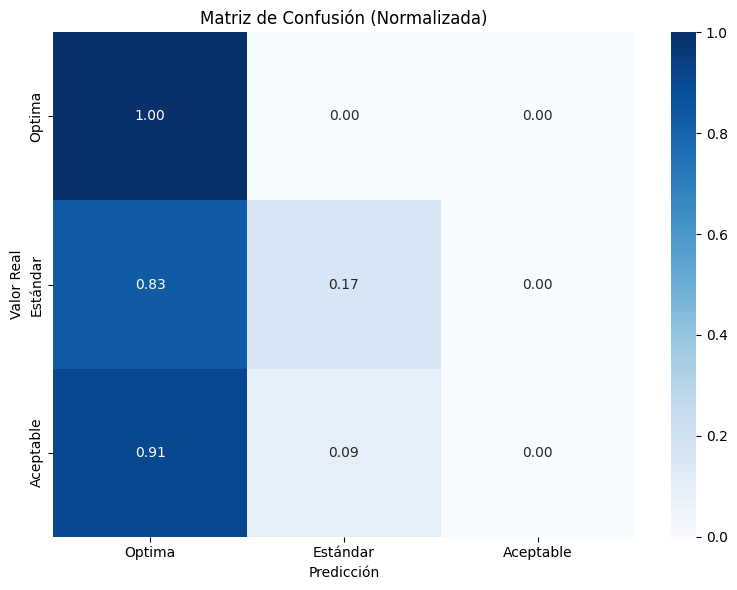


🎯 ANALIZANDO ERRORES POR CLASE...


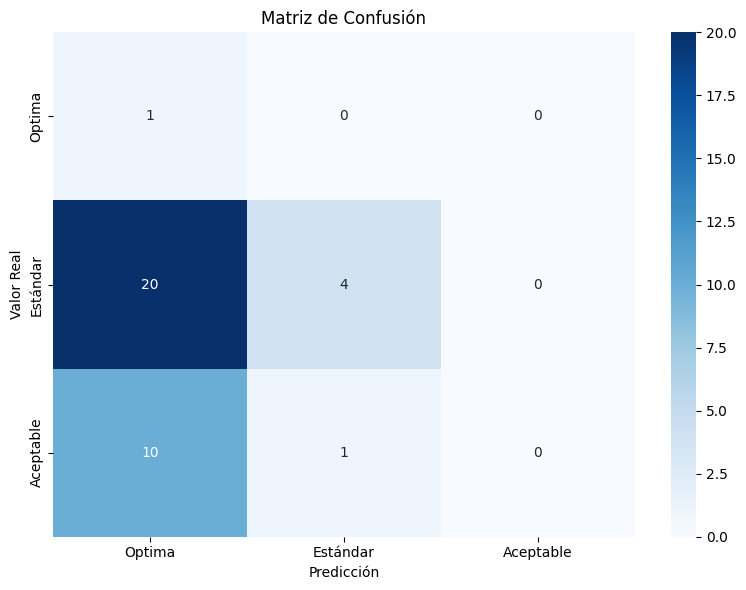


🔍 ANÁLISIS DE ERRORES POR CLASE:

📊 CLASE: Optima
  - Total muestras: 1
  - Correctas: 1
  - Accuracy: 100.00%

📊 CLASE: Estándar
  - Total muestras: 24
  - Correctas: 4
  - Accuracy: 16.67%
  - Se confunde con Optima: 20 muestras (83.3%)

📊 CLASE: Aceptable
  - Total muestras: 11
  - Correctas: 0
  - Accuracy: 0.00%
  - Se confunde con Optima: 10 muestras (90.9%)
  - Se confunde con Estándar: 1 muestras (9.1%)

ACTIVIDAD 4.3 - OPTIMIZACIÓN BASADA EN RESULTADOS
💡 RECOMENDACIONES DE OPTIMIZACIÓN:
  - 🔴 PROBLEMA: Accuracy baja en test (< 70%)
  - 🎯 SOLUCIÓN: Probar arquitectura [128, 64] o [256, 128, 64]
  - 🔴 PROBLEMA: R² bajo - modelo no explica bien la varianza
  - 🎯 SOLUCIÓN: Probar diferentes funciones de activación

📋 RESUMEN EJECUTIVO
✅ Modelo: 141 → 64 → 1
✅ Épocas: 100
✅ Test Accuracy: 30.56%
✅ Test R²: -0.1064


In [ ]:
# EJECUTAR TODO EN ESTE ORDEN:

# 1. Definir la clase CompleteTrainer COMPLETA (con todos los métodos)
# 2. Crear modelo
modelo = MLP_Apple(
    input_size=141, 
    hidden_layers=[64], 
    outputs_size=1, 
    activation='relu'
    dropout_rate=0.2
)
print(f"\n{'='*60}")
print("ACTIVIDAD 4.1 - VALIDACIÓN CON DATOS DE PRUEBA")
print(f"{'='*60}")

# 1. Evaluar en TEST (datos nunca vistos)
test_loss, test_metrics = trainer.validate_with_metrics(test_loader)
print("📊 MÉTRICAS FINALES EN TEST:")
print(f"  - Loss: {test_loss:.4f}")
print(f"  - Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  - R²: {test_metrics['r2']:.4f}")
print(f"  - F1-Score: {test_metrics['f1_macro']:.4f}")
print(f"  - RMSE: {test_metrics['rmse']:.4f}")
print(f"  - MAE: {test_metrics['mae']:.4f}")

print(f"\n{'='*60}")
print("ACTIVIDAD 4.2 - ANÁLISIS DE ERROR POR TIPO DE MUESTRA")
print(f"{'='*60}")

# 2. Crear NUEVO trainer con métodos actualizados (sin la función duplicada)
print("🔄 Creando trainer actualizado...")
trainer_actualizado = CompleteTrainer(modelo)
trainer_actualizado.history = trainer.history  # Copiar historial de entrenamiento

print("🎯 GENERANDO MATRIZ DE CONFUSIÓN...")
matriz = trainer_actualizado.generate_confusion_matrix(test_loader)

print("\n🎯 ANALIZANDO ERRORES POR CLASE...")
trainer_actualizado.analyze_errors_by_class(test_loader)

print(f"\n{'='*60}")
print("ACTIVIDAD 4.3 - OPTIMIZACIÓN BASADA EN RESULTADOS")
print(f"{'='*60}")

# 3. Recomendaciones de optimización
print("💡 RECOMENDACIONES DE OPTIMIZACIÓN:")

if test_metrics['accuracy'] < 0.7:
    print("  - 🔴 PROBLEMA: Accuracy baja en test (< 70%)")
    print("  - 🎯 SOLUCIÓN: Probar arquitectura [128, 64] o [256, 128, 64]")
elif test_metrics['accuracy'] < 0.8:
    print("  - 🟡 PROBLEMA: Accuracy moderada (70-80%)")
    print("  - 🎯 SOLUCIÓN: Probar activaciones ReLU/tanh o más épocas")
else:
    print("  - ✅ EXCELENTE: Accuracy alta (> 80%)")

if test_metrics['r2'] < 0.6:
    print("  - 🔴 PROBLEMA: R² bajo - modelo no explica bien la varianza")
    print("  - 🎯 SOLUCIÓN: Probar diferentes funciones de activación")
elif test_metrics['r2'] < 0.8:
    print("  - 🟡 PROBLEMA: R² moderado")
    print("  - 🎯 SOLUCIÓN: Ajustar learning rate")
else:
    print("  - ✅ EXCELENTE: R² alto - buen poder predictivo")

# Análisis de sobreajuste
overfitting_ratio = test_loss / trainer.history['train_loss'][-1]
if overfitting_ratio > 1.2:
    print("  - 🔴 PROBLEMA: Posible sobreajuste")
    print("  - 🎯 SOLUCIÓN: Agregar dropout (dropout_rate=0.2-0.5)")

print(f"\n{'='*60}")
print("📋 RESUMEN EJECUTIVO")
print(f"{'='*60}")
print(f"✅ Modelo: 141 → 64 → 1")
# print(f"✅ Optimizador: SGD")
# print(f"✅ Activación: Sigmoid") 
print(f"✅ Épocas: {len(trainer.history['epoch'])}")
print(f"✅ Test Accuracy: {test_metrics['accuracy']:.2%}")
print(f"✅ Test R²: {test_metrics['r2']:.4f}")


# # 3. Crear trainer (AHORA con todos los métodos)
# trainer = CompleteTrainer(modelo)
# trainer.setup_training(optimizer_name='sgd', lr=0.01, criterion_name='mse')

# # 4. Entrenar
# history = trainer.train(train_loader, val_loader, epochs=100)

# # 5. Generar gráficas
# trainer.plot_training_curves()

# # 6. ✅ AHORA SÍ - Actividades 4.1, 4.2, 4.3
# print(f"\n{'='*60}")
# print("ACTIVIDAD 4.1 - VALIDACIÓN CON DATOS DE PRUEBA")
# print(f"{'='*60}")

# test_loss, test_metrics = trainer.validate_with_metrics(test_loader)
# print("📊 MÉTRICAS EN TEST:")
# print(f"  - Loss: {test_loss:.4f}")
# print(f"  - Accuracy: {test_metrics['accuracy']:.4f}")

# print(f"\n{'='*60}")
# print("ACTIVIDAD 4.2 - ANÁLISIS DE ERROR POR TIPO DE MUESTRA") 
# print(f"{'='*60}")

# matriz = trainer.generate_confusion_matrix(test_loader)
# trainer.analyze_errors_by_class(test_loader)

# print(f"\n{'='*60}")
# print("ACTIVIDAD 4.3 - OPTIMIZACIÓN BASADA EN RESULTADOS")
# print(f"{'='*60}")

# # Tus análisis de optimización aquí...

In [ ]:
!ls -la *.csv
!ls -la *.png

-rw-r--r-- 1 root root 30012 Dec  1 02:15 metricas_entrenamiento.csv
-rw-r--r-- 1 root root 30012 Dec  1 02:26 metricas_modelo_propuesto.csv
-rw-r--r-- 1 root root 564844 Dec  1 02:15 graficas_entrenamiento.png
-rw-r--r-- 1 root root 573782 Dec  1 02:26 graficas_modelo_propuesto.png
